# **Telecom Customer Churn Prediction**

## Key Conclusions

1. **26.58%** overall churn rate detected across 7,032 customers
2. **31.84%** of churned users were on Monthly contract with tenure <= 3 months — early engagement strategy needed
3. Churned customers pay **₹13 more** on average monthly charges than retained customers
4. **25.47%** of churned customers are Senior Citizens — targeted retention plans needed
5. Fiber Optic Internet Service users show significantly higher churn
6. Electronic check payment method has highest churn among all payment methods

In [1]:
# import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# read dataset
df = pd.read_csv('https://github.com/YBIFoundation/Dataset/raw/main/TelecomCustomerChurn.csv')

In [3]:
df = pd.read_csv('https://github.com/YBIFoundation/Dataset/raw/main/TelecomCustomerChurn.csv')
df.shape

(7043, 21)

In [4]:
df.head()

,customerID,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No,DSL,No,...,No,No,No,No,Monthly,Yes,Manual,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Manual,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Monthly,Yes,Manual,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Monthly,Yes,Manual,70.70,151.65,Yes


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   Gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   Tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.isnull().sum()

customerID           0
Gender               0
SeniorCitizen        0
Partner              0
Dependents           0
Tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [7]:
df.dropna(inplace=True)
print("Rows after cleaning:", df.shape[0])

Rows after cleaning: 7032


In [8]:
df.describe()

,SeniorCitizen,Tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441
std,0.368844,24.545260,30.085974,2266.771362
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.587500,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.862500,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [9]:
df['Churn'].value_counts()

Churn
No     5163
Yes    1869
Name: count, dtype: int64

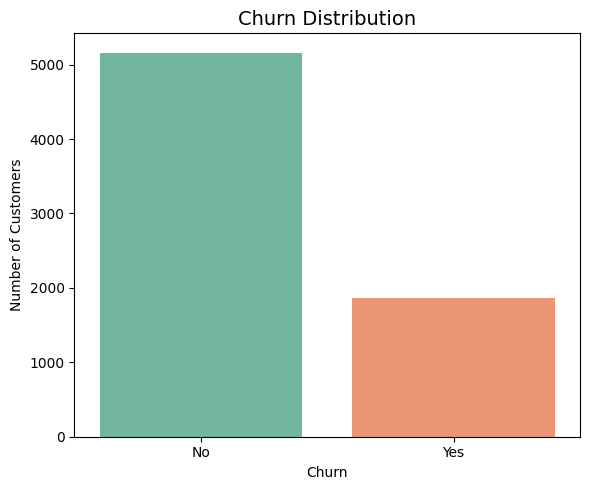

Churn Rate: 26.58 %


In [10]:
# Visualization 1 - Churn Distribution
plt.figure(figsize=(6,5))
sns.countplot(x='Churn', data=df, palette='Set2')
plt.title('Churn Distribution', fontsize=14)
plt.xlabel('Churn')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

print("Churn Rate:", round(1869/7032*100, 2), "%")

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


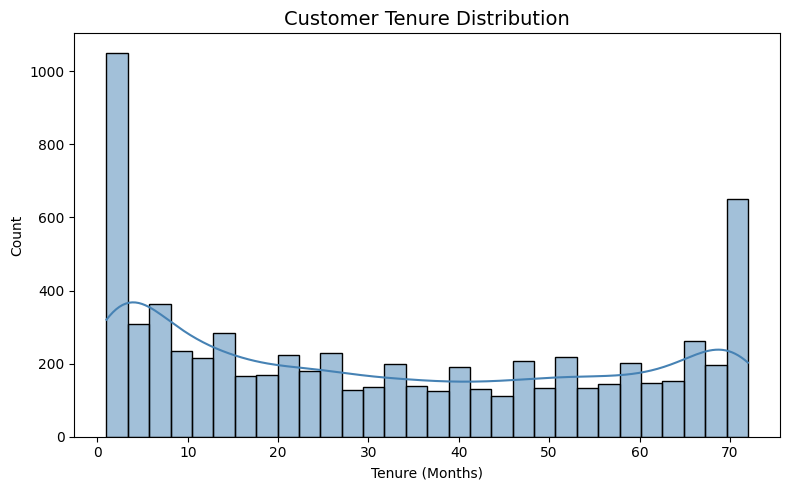

In [11]:
# Visualization 2 - Tenure Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['Tenure'], bins=30, kde=True, color='steelblue')
plt.title('Customer Tenure Distribution', fontsize=14)
plt.xlabel('Tenure (Months)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

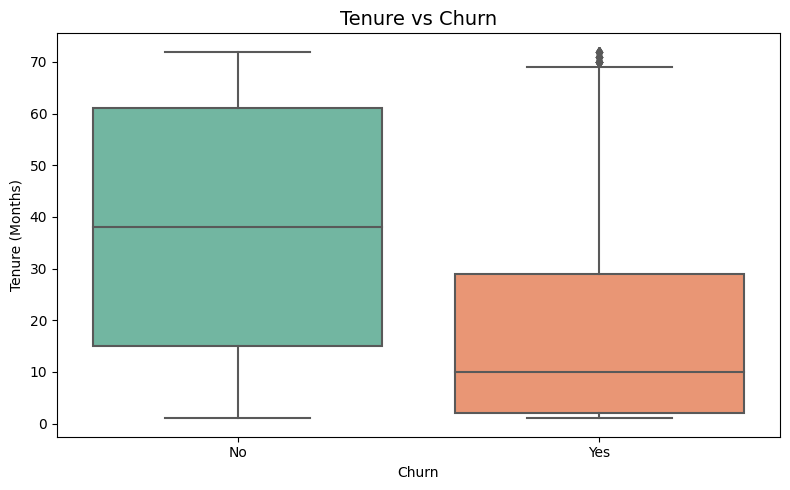

In [12]:
# Visualization 3 - Tenure vs Churn
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn', y='Tenure', data=df, palette='Set2')
plt.title('Tenure vs Churn', fontsize=14)
plt.xlabel('Churn')
plt.ylabel('Tenure (Months)')
plt.tight_layout()
plt.show()

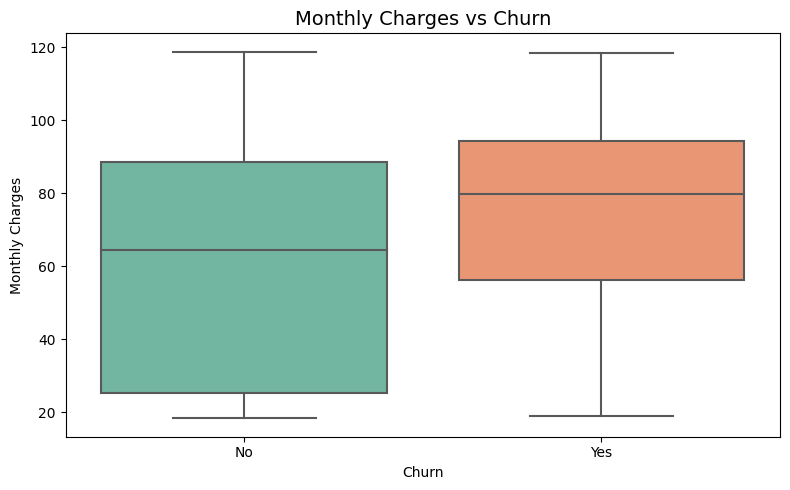

In [13]:
# Visualization 4 - Monthly Charges vs Churn
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df, palette='Set2')
plt.title('Monthly Charges vs Churn', fontsize=14)
plt.xlabel('Churn')
plt.ylabel('Monthly Charges')
plt.tight_layout()
plt.show()

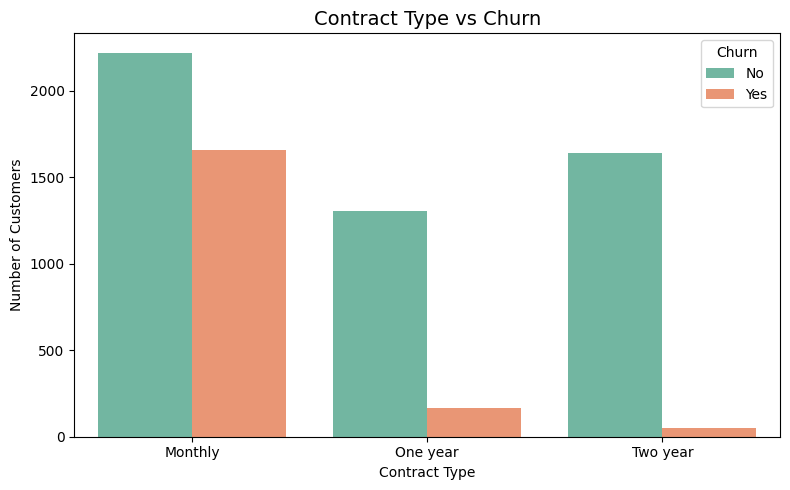

In [14]:
# Visualization 5 - Contract Type vs Churn
plt.figure(figsize=(8,5))
sns.countplot(x='Contract', hue='Churn', data=df, palette='Set2')
plt.title('Contract Type vs Churn', fontsize=14)
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

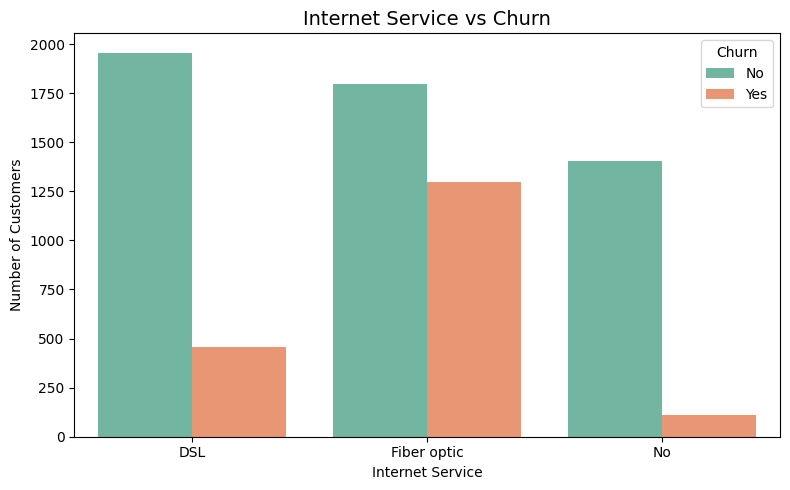

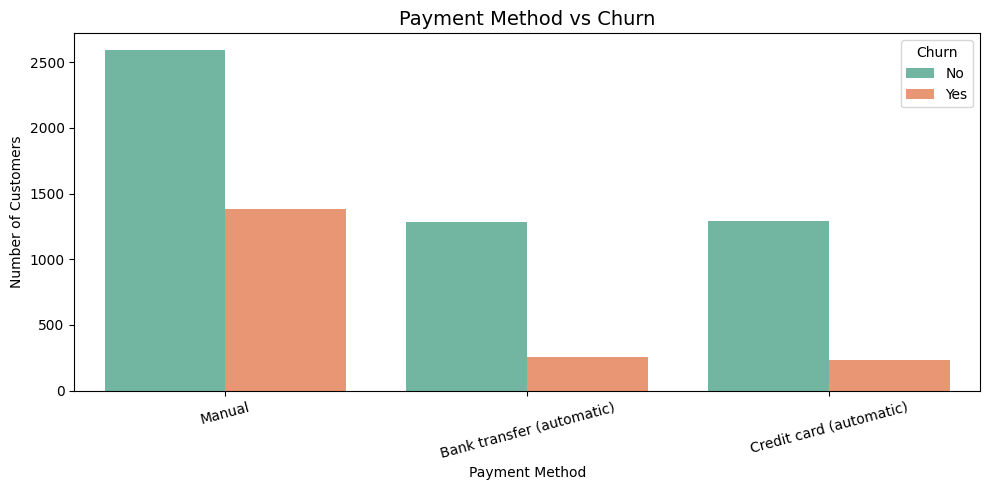

In [15]:
# Visualization 6 - Internet Service vs Churn
plt.figure(figsize=(8,5))
sns.countplot(x='InternetService', hue='Churn', data=df, palette='Set2')
plt.title('Internet Service vs Churn', fontsize=14)
plt.xlabel('Internet Service')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()# Visualization 7 - Payment Method vs Churn
plt.figure(figsize=(10,5))
sns.countplot(x='PaymentMethod', hue='Churn', data=df, palette='Set2')
plt.title('Payment Method vs Churn', fontsize=14)
plt.xlabel('Payment Method')
plt.ylabel('Number of Customers')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

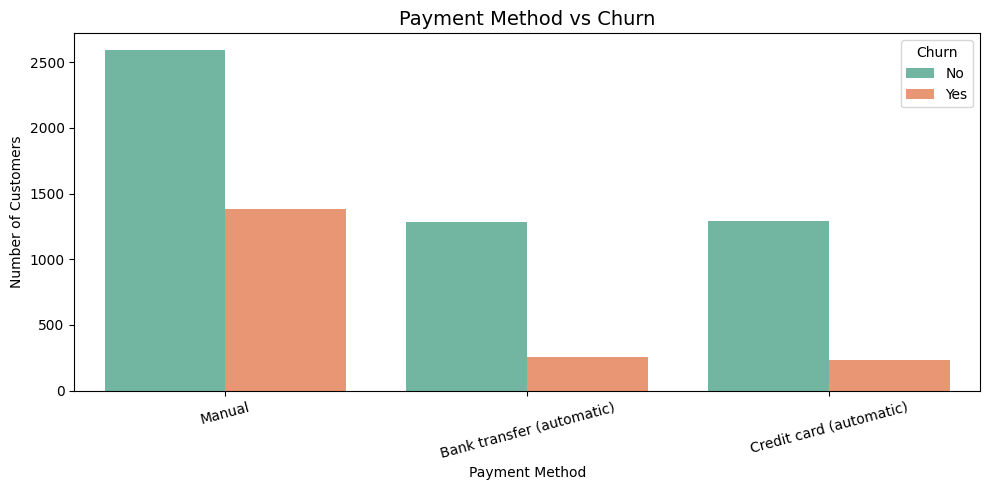

In [16]:
# Visualization 7 - Payment Method vs Churn
plt.figure(figsize=(10,5))
sns.countplot(x='PaymentMethod', hue='Churn', data=df, palette='Set2')
plt.title('Payment Method vs Churn', fontsize=14)
plt.xlabel('Payment Method')
plt.ylabel('Number of Customers')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

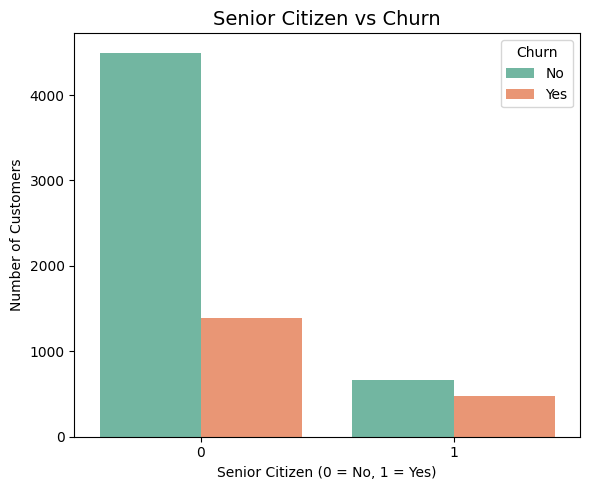

In [17]:
# Visualization 8 - Senior Citizen vs Churn
plt.figure(figsize=(6,5))
sns.countplot(x='SeniorCitizen', hue='Churn', data=df, palette='Set2')
plt.title('Senior Citizen vs Churn', fontsize=14)
plt.xlabel('Senior Citizen (0 = No, 1 = Yes)')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

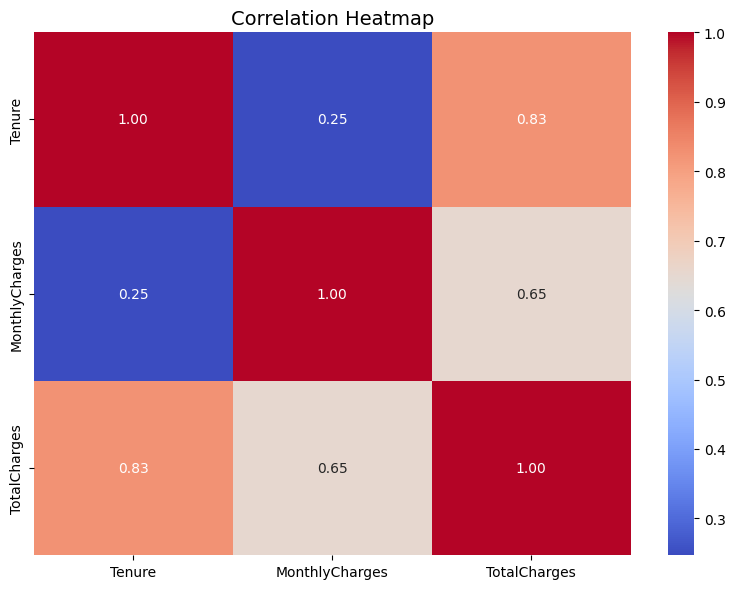

In [18]:
# Visualization 9 - Correlation Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df[['Tenure', 'MonthlyCharges', 'TotalCharges']].corr(), 
            annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

/opt/conda/lib/python3.10/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
/opt/conda/lib/python3.10/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


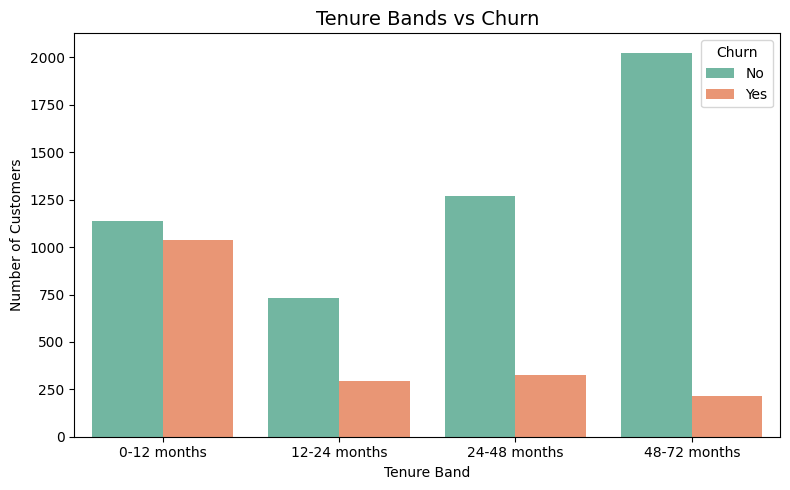

In [19]:
# Visualization 10 - Tenure Bands vs Churn
df['TenureBand'] = pd.cut(df['Tenure'], bins=[0,12,24,48,72], 
                           labels=['0-12 months','12-24 months','24-48 months','48-72 months'])

plt.figure(figsize=(8,5))
sns.countplot(x='TenureBand', hue='Churn', data=df, palette='Set2')
plt.title('Tenure Bands vs Churn', fontsize=14)
plt.xlabel('Tenure Band')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

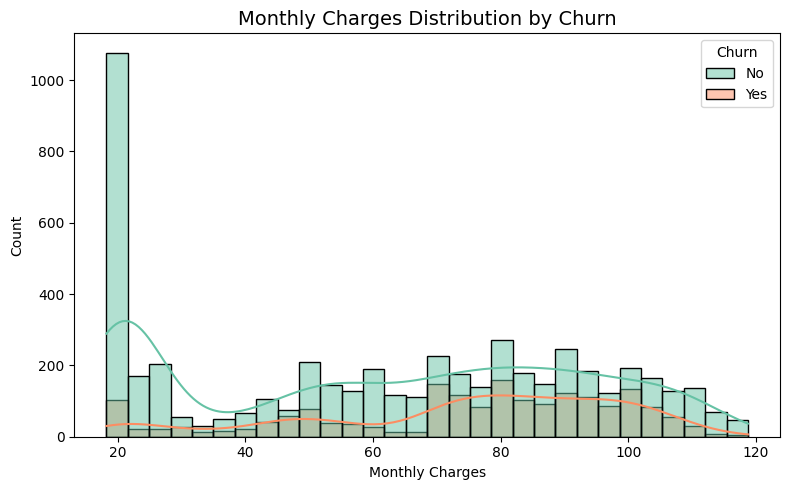

In [20]:
# Visualization 11 - Monthly Charges Distribution by Churn
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='MonthlyCharges', hue='Churn', bins=30, kde=True, palette='Set2')
plt.title('Monthly Charges Distribution by Churn', fontsize=14)
plt.xlabel('Monthly Charges')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [21]:
print(df['Contract'].unique())
print(df['Tenure'].unique()[:10])

['Monthly' 'One year' 'Two year']
[ 1 34  2 45  8 22 10 28 62 13]


In [22]:
# Key Insights
total_churned = df[df['Churn'] == 'Yes'].shape[0]

# Insight 1 - Churn Rate
churn_rate = round(total_churned / df.shape[0] * 100, 2)
print(f"1. Overall Churn Rate: {churn_rate}%")

# Insight 2 - Monthly contract + less than 3 months tenure
monthly_short = df[(df['Churn'] == 'Yes') & 
                   (df['Contract'] == 'Monthly') & 
                   (df['Tenure'] <= 3)].shape[0]
pct = round(monthly_short / total_churned * 100, 2)
print(f"2. Churned users on monthly contract with tenure <= 3 months: {pct}%")

# Insight 3 - Avg Monthly Charges
avg_churn = round(df[df['Churn']=='Yes']['MonthlyCharges'].mean(), 2)
avg_no_churn = round(df[df['Churn']=='No']['MonthlyCharges'].mean(), 2)
print(f"3. Avg Monthly Charges - Churned: {avg_churn} | Retained: {avg_no_churn}")

# Insight 4 - Senior Citizen churn
senior_churn = df[(df['Churn']=='Yes') & (df['SeniorCitizen']==1)].shape[0]
senior_pct = round(senior_churn / total_churned * 100, 2)
print(f"4. Senior Citizens among churned customers: {senior_pct}%")

1. Overall Churn Rate: 26.58%
2. Churned users on monthly contract with tenure <= 3 months: 31.84%
3. Avg Monthly Charges - Churned: 74.44 | Retained: 61.31
4. Senior Citizens among churned customers: 25.47%
